In [71]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import csv
np.random.seed(42)

In [59]:
df = pd.read_csv("population_data_2024.csv", header=4)

In [40]:
df.head()

,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
2,AFG,Middle East & North Africa,Low income,The reporting period for national accounts dat...,Afghanistan,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
4,AGO,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola,NaN


In [61]:
df = df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Population'
)
df.columns = ['Country_Name', 'Country_Code', 'Indicator_Name', 'Indicator_Code', 'Year', 'Population']

In [62]:
# No header rows need dropping because the file is read with header=4.

In [43]:
df.head().reset_index(drop=True)

,Country_Name,Country_Code,Indicator_Name,Indicator_Code,Year,Population
0,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
1,AGO,Sub-Saharan Africa,Lower middle income,The World Bank systematically assesses the app...,Angola,NaN
2,ALB,Europe & Central Asia,Upper middle income,NaN,Albania,NaN
3,AND,Europe & Central Asia,High income,NaN,Andorra,NaN
4,ARB,NaN,NaN,Arab World aggregate. Arab World is composed o...,Arab World,NaN


In [63]:
df.isnull().sum()

Country_Name        0
Country_Code        0
Indicator_Name      0
Indicator_Code      0
Year                0
Population        361
dtype: int64

# For Imputing the values we are using KNN-Imputer

In [65]:
from sklearn.impute import KNNImputer

# Use the reshaped population dataframe from the previous cells.
df_imputed = df.copy()
df_imputed['Population'] = pd.to_numeric(df_imputed['Population'], errors='coerce')

imputer = KNNImputer(n_neighbors=5)
df_imputed['Population'] = imputer.fit_transform(df_imputed[['Population']])
print('Imputed df shape:', df_imputed.shape)
print('Population nulls after imputation:', df_imputed['Population'].isnull().sum())

Imputed df shape: (17556, 6)
Population nulls after imputation: 0


In [66]:
df_imputed.isnull().sum()

Country_Name      0
Country_Code      0
Indicator_Name    0
Indicator_Code    0
Year              0
Population        0
dtype: int64

In [69]:
df_imputed

,Country_Name,Country_Code,Indicator_Name,Indicator_Code,Year,Population
0,Aruba,ABW,"Population, total",SP.POP.TOTL,1960,5.492200e+04
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,1960,1.300757e+08
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,1960,9.035043e+06
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,1960,9.763092e+07
4,Angola,AGO,"Population, total",SP.POP.TOTL,1960,5.231654e+06
...,...,...,...,...,...,...
17551,Kosovo,XKX,"Population, total",SP.POP.TOTL,2025,2.182379e+08
17552,"Yemen, Rep.",YEM,"Population, total",SP.POP.TOTL,2025,2.182379e+08
17553,South Africa,ZAF,"Population, total",SP.POP.TOTL,2025,2.182379e+08
17554,Zambia,ZMB,"Population, total",SP.POP.TOTL,2025,2.182379e+08


In [72]:
with open('output_list.csv', 'w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerows(df_imputed)

# Analysizing

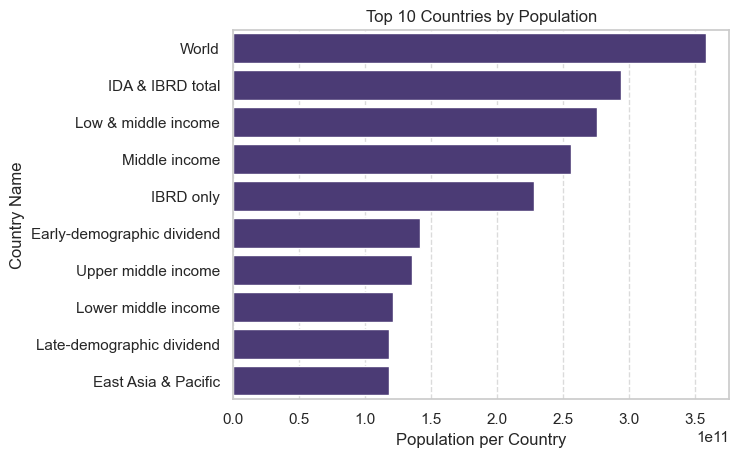

In [89]:
df=df_imputed

population_per_country = df.groupby('Country_Name')['Population'].sum().reset_index(name='Population per Country')

sns.set_theme(style="whitegrid",palette="viridis")
sns.barplot(x='Population per Country', y='Country_Name', data=population_per_country.sort_values('Population per Country', ascending=False, inplace=False,).head(10))
plt.title('Top 10 Countries by Population')
plt.xlabel('Population per Country')
plt.ylabel('Country Name')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.savefig("top_10_countries_by_population.png", dpi=300)
plt.show()


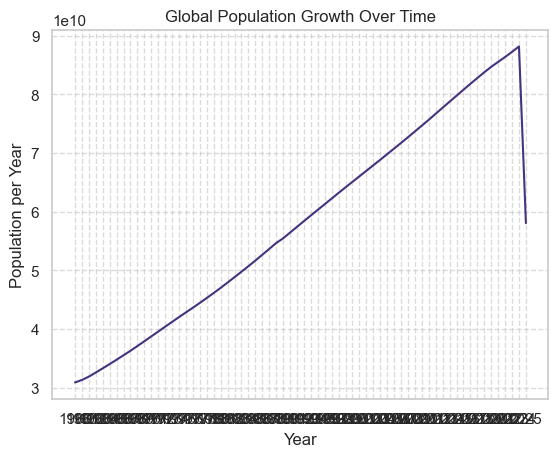

In [85]:
population_per_year = df.groupby('Year')['Population'].sum().reset_index(name='Population per Year')
sns.set_theme(style="whitegrid",palette="viridis")
sns.lineplot(x='Year', y='Population per Year', data=population_per_year)
plt.title('Global Population Growth Over Time')
plt.xlabel('Year')
plt.ylabel('Population per Year')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

C:\Users\laksh\AppData\Local\Temp\ipykernel_21772\1230652331.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Population', y='Country_Name', data=top_10_clean, ax=axes[1], color='steelblue', dodge=False)


Saved perfect plot.


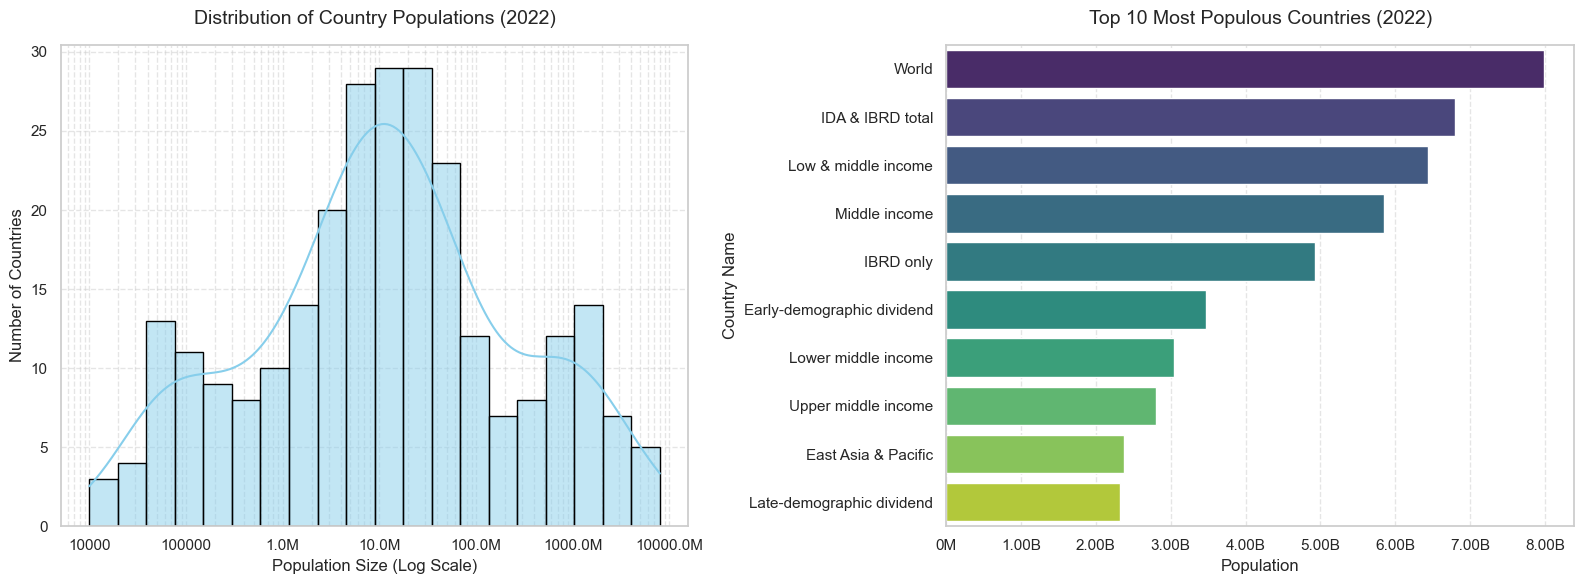

In [ ]:
from matplotlib import ticker

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_2022 = df[df['Year'].astype(str) == '2022'].copy()
df_2022['Population'] = pd.to_numeric(df_2022['Population'], errors='coerce')

sns.histplot(df_2022['Population'].dropna(), bins=20, log_scale=True, kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Country Populations (2022)', fontsize=14, pad=15)
axes[0].set_xlabel('Population Size (Log Scale)', fontsize=12)
axes[0].set_ylabel('Number of Countries', fontsize=12)
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M' if x >= 1e6 else f'{x:.0f}'))
axes[0].grid(True, which="both", ls="--", alpha=0.5)

top_10_clean = df_2022.sort_values('Population', ascending=False).head(10)
sns.barplot(x='Population', y='Country_Name', data=top_10_clean, ax=axes[1], color='steelblue', dodge=False)
axes[1].set_title('Top 10 Most Populous Countries (2022)', fontsize=14, pad=15)
axes[1].set_xlabel('Population', fontsize=12)
axes[1].set_ylabel('Country Name', fontsize=12)
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-9:.2f}B' if x >= 1e9 else f'{x*1e-6:.0f}M'))
axes[1].grid(True, axis='x', ls="--", alpha=0.5)

plt.tight_layout()
fig.savefig('population_distribution_perfect.png', dpi=300)
print("Saved perfect plot.")